# 🏠 House Prices Dataset Overview

This dataset contains detailed information about residential houses and is used to build machine learning models that predict **house prices** based on property characteristics, location, and condition.

It combines both **numerical features (size, rooms, area)** and **categorical features (city, street, state)** to represent real-world housing data.

---

# 📊 Columns Explanation

## 📅 date
- The date when the house was sold
- Helps analyze market trends over time

---

## 💰 price
- The target variable (label)
- Represents the selling price of the house

---

## 🛏️ bedrooms
- Number of bedrooms in the house
- Indicates size and capacity of the property

---

## 🛁 bathrooms
- Number of bathrooms
- Includes full and partial bathrooms (e.g., 2.5 = 2 full + 1 half bathroom)

---

## 📐 sqft_living
- Total interior living space in square feet
- Main area where people live (living room, bedrooms, etc.)

---

## 🌍 sqft_lot
- Total land area of the property
- Includes yard, garden, and unused outdoor space

---

## 🏢 floors
- Number of floors in the house
- Example: 1, 1.5, 2 floors

---

## 🌊 waterfront
- Binary indicator (0 or 1)
- 1 = house is located on waterfront (sea/lake view)
- 0 = not waterfront

---

## 👀 view
- Quality of the view from the house
- Usually a score (0 to 4), higher = better view

---

## 🏚️ condition
- Overall condition of the house
- Scale typically from 1 (bad) to 5 (excellent)

---

## 🧱 sqft_above
- Square footage of the house above ground level
- Excludes basement area

---

## 🏠 sqft_basement
- Square footage of the basement area
- Important for total usable space

---

## 📅 yr_built
- Year the house was originally built
- Helps understand age of property

---

## 🔧 yr_renovated
- Year the house was last renovated
- 0 usually means never renovated

---

## 🛣️ street
- Street address of the house
- Useful for location-based patterns

---

## 🏙️ city
- City where the house is located
- Strong factor affecting price

---

## 📍 statezip
- Combined state and ZIP code
- Used for regional pricing differences

---

## 🌎 country
- Country of the property
- Usually constant in this dataset (e.g., USA)

---

# 🧠 What You Did in This Project (End-to-End ML Workflow)

## 🧹 1. Data Cleaning
- Handled missing values (if any)
- Checked for duplicates
- Verified data types (date, numeric, categorical)
- Treated inconsistent values (e.g., yr_renovated = 0 meaning no renovation)

---

## 📊 2. Exploratory Data Analysis (EDA)
- Analyzed distribution of house prices
- Studied relationships between price and features (sqft_living, location, etc.)
- Checked correlations between variables
- Identified important patterns (e.g., waterfront houses are more expensive)
- Visualized trends using plots (histograms, scatter plots, heatmaps)

---

## 🛠️ 3. Feature Engineering
- Created new features such as:
  - house age = current year - yr_built
  - total sqft = sqft_above + sqft_basement
  - price per sqft
  - renovation indicators
- Converted raw data into more meaningful signals for the model

---

## ⚙️ 4. Data Preprocessing
- Encoded categorical features (city, street if used)
- Scaled numerical features using StandardScaler
- Split dataset into training and testing sets
- Prepared final feature matrix (X) and target variable (y)

---

## 🤖 5. Machine Learning Models
Built and trained multiple regression models:

- Linear Regression (baseline)
- Decision Tree Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

Each model learned patterns between house features and price.

---

## 📈 6. Model Evaluation
Evaluated models using:

- **RMSE (Root Mean Squared Error)** → measures prediction error
- **R² Score** → measures how well the model explains variance

Comparison helped identify the best-performing model (usually Gradient Boosting or XGBoost for tabular data).

---

# 🧠 Final Insight
This project demonstrates a full **end-to-end Data Science pipeline**:

> From raw housing data → cleaning → insights → feature engineering → modeling → evaluation → model comparison

It simulates a real-world **real estate price prediction system** used in industry-level machine learning applications.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

housing = pd.read_csv(r"C:\Users\user\Downloads\data.csv")
housing.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [20]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [21]:
housing.describe().T

,count,mean,std,min,25%,50%,75%,max
price,4600.0,551962.988473,563834.702547,0.0,322875.00,460943.461539,654962.50,26590000.0
bedrooms,4600.0,3.400870,0.908848,0.0,3.00,3.000000,4.00,9.0
bathrooms,4600.0,2.160815,0.783781,0.0,1.75,2.250000,2.50,8.0
sqft_living,4600.0,2139.346957,963.206916,370.0,1460.00,1980.000000,2620.00,13540.0
sqft_lot,4600.0,14852.516087,35884.436145,638.0,5000.75,7683.000000,11001.25,1074218.0
floors,4600.0,1.512065,0.538288,1.0,1.00,1.500000,2.00,3.5
waterfront,4600.0,0.007174,0.084404,0.0,0.00,0.000000,0.00,1.0
view,4600.0,0.240652,0.778405,0.0,0.00,0.000000,0.00,4.0
condition,4600.0,3.451739,0.677230,1.0,3.00,3.000000,4.00,5.0
sqft_above,4600.0,1827.265435,862.168977,370.0,1190.00,1590.000000,2300.00,9410.0


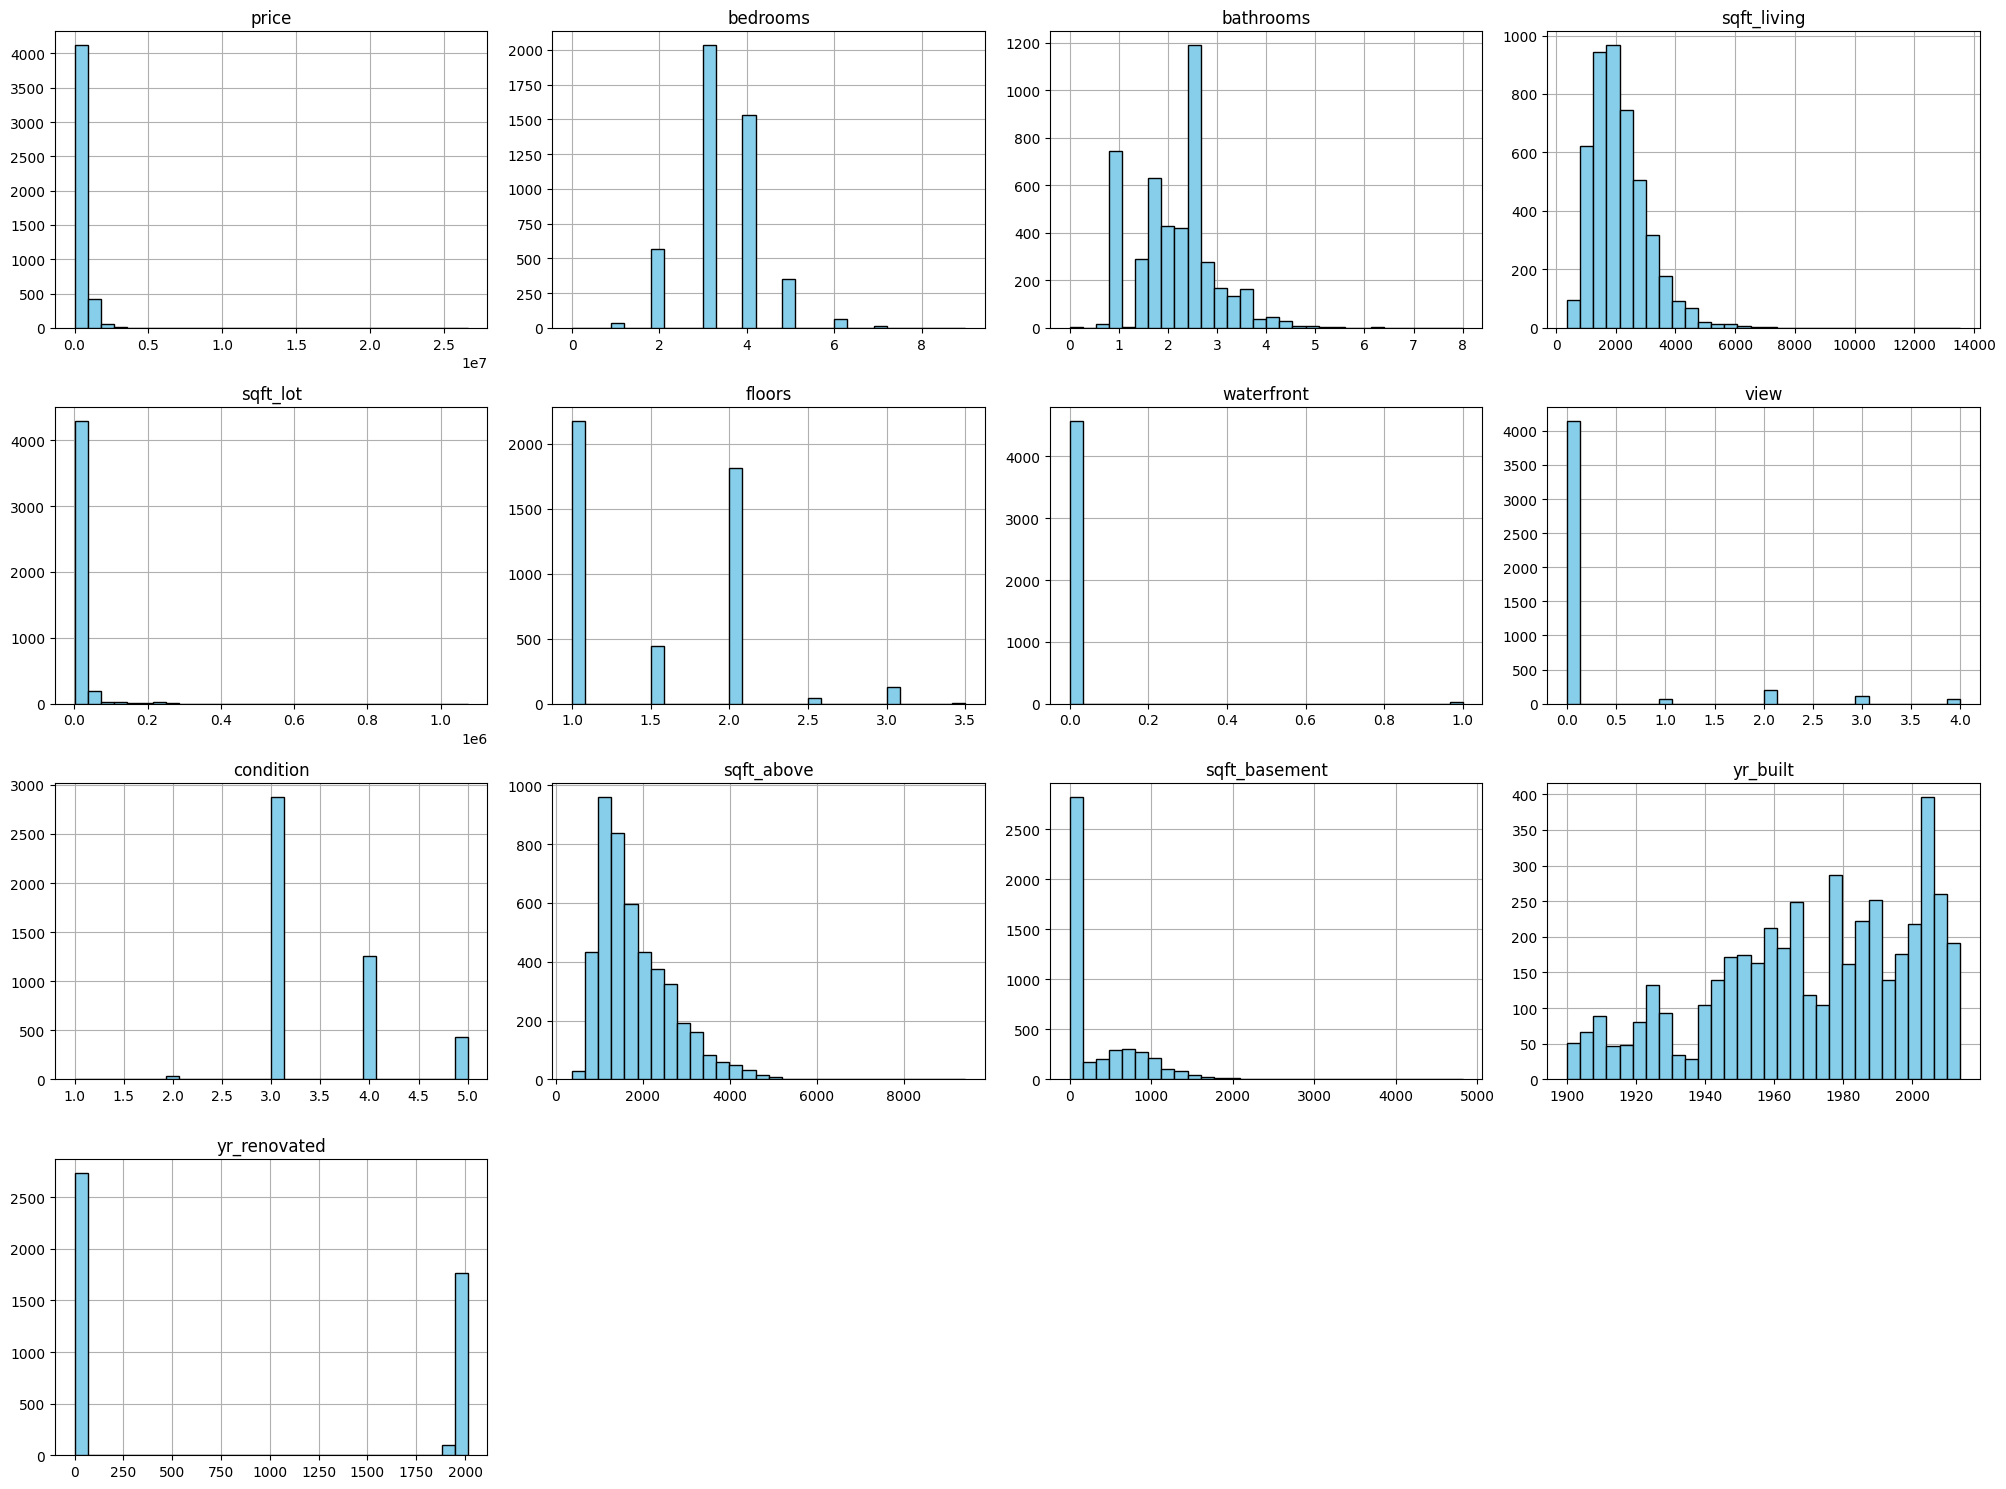

In [22]:
housing.hist(edgecolor='black', bins=30, figsize=(20, 15), zorder=5, color='skyblue')
plt.tight_layout()
plt.show()

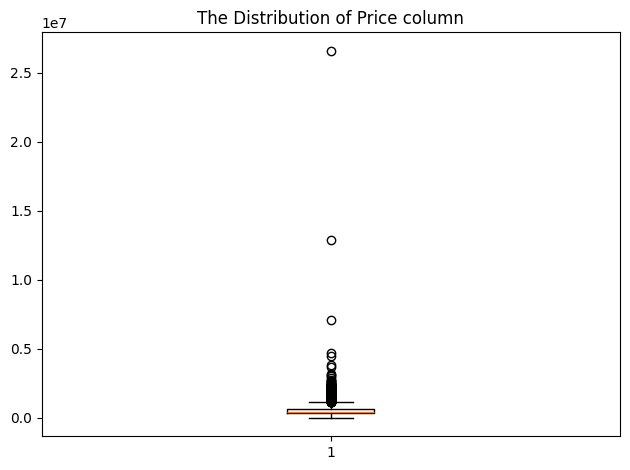

In [23]:
# Plot the price box plot
plt.boxplot(housing['price'])
plt.title("The Distribution of Price column")
plt.tight_layout()
plt.show()

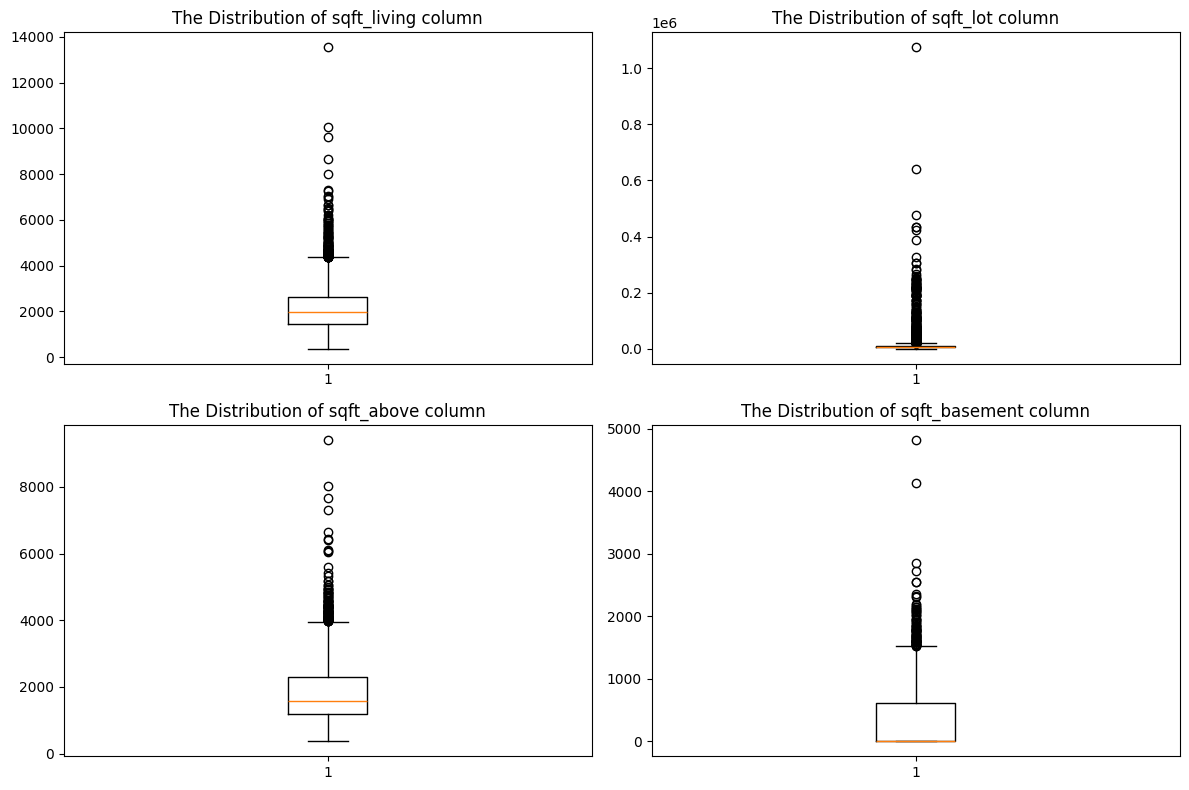

In [24]:
fig, axes = plt.subplots(nrows=2, ncols=2)
plt.gcf().set_size_inches(12, 8)

def plot_boxplot_axes(axes, column):
    axes.boxplot(housing[column])
    axes.set_title(f"The Distribution of {column} column")

plot_boxplot_axes(axes[0, 0], 'sqft_living')
plot_boxplot_axes(axes[0, 1], 'sqft_lot')
plot_boxplot_axes(axes[1, 0], 'sqft_above')
plot_boxplot_axes(axes[1, 1], 'sqft_basement')
plt.tight_layout()
plt.show()

In [25]:
housing = housing.loc[(housing['price'] < 0.25e7) & (housing['sqft_living'] < 6000) &
                    (housing['sqft_lot'] < 0.05e6) & (housing['sqft_above'] < 5000) & (housing['sqft_basement'] < 1500)]

In [26]:
housing['country'].value_counts()

country
USA    4314
Name: count, dtype: int64

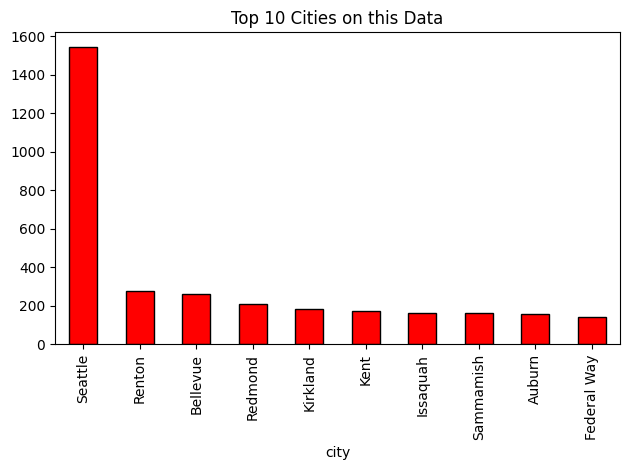

In [27]:
housing['city'].value_counts().iloc[:10].plot(kind='bar', edgecolor='black', color='red')
plt.title("Top 10 Cities on this Data")
plt.tight_layout()
plt.show()

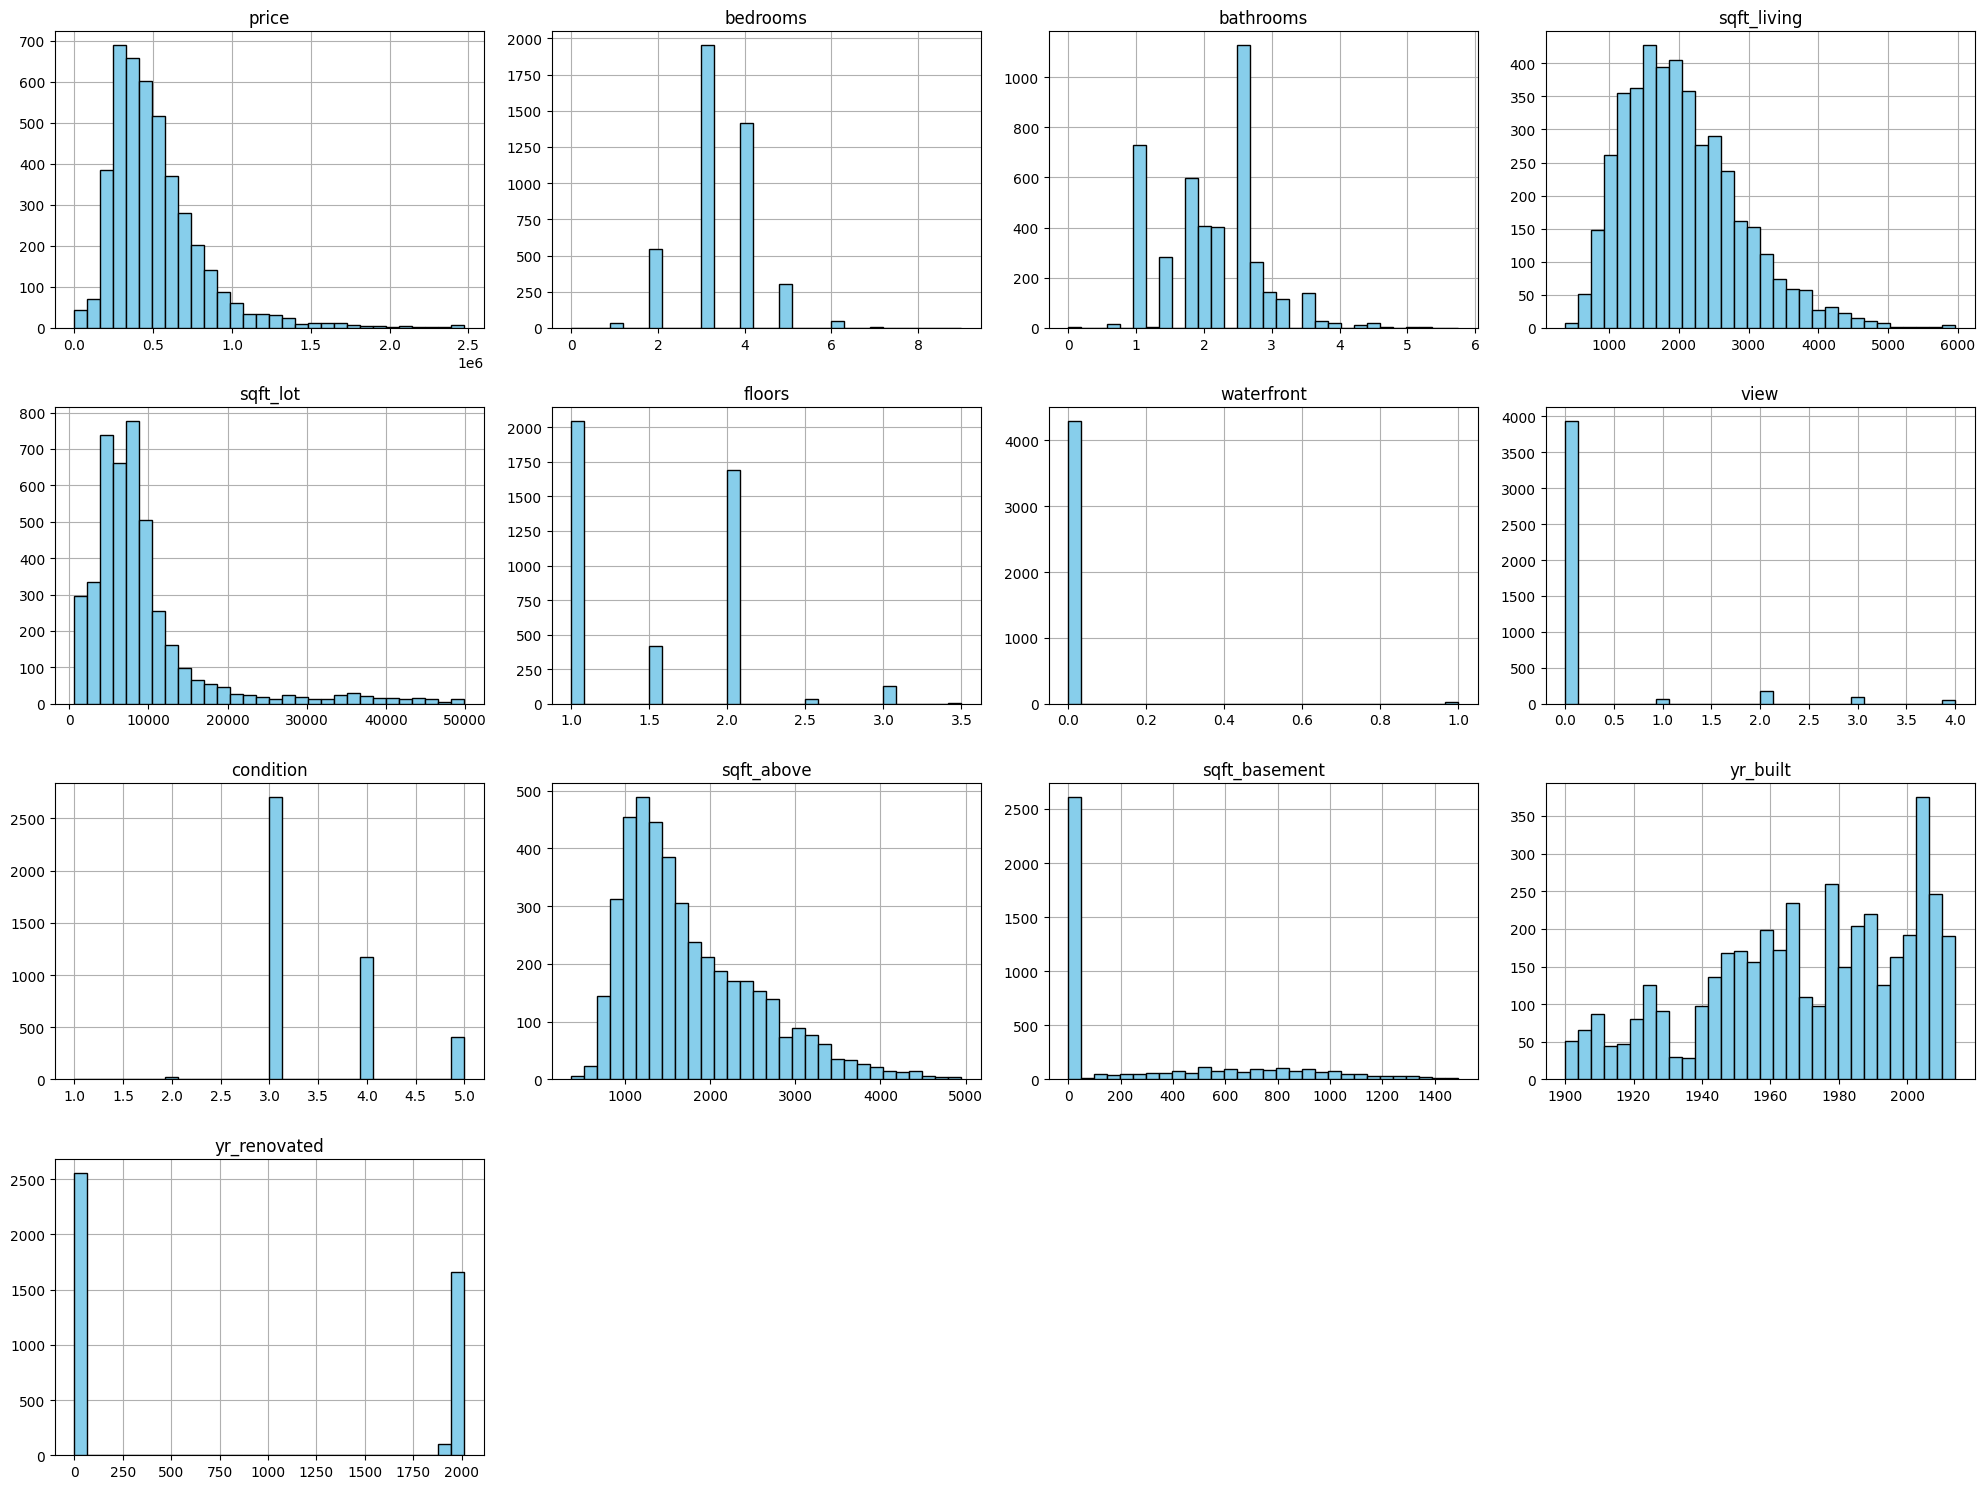

In [28]:
housing.hist(edgecolor='black', bins=30, figsize=(20, 15), zorder=5, color='skyblue')
plt.tight_layout()
plt.show()

In [29]:
housing.select_dtypes(include=np.number).skew()

price             2.048837
bedrooms          0.421625
bathrooms         0.283783
sqft_living       0.861861
sqft_lot          2.607186
floors            0.569614
waterfront       13.590401
view              3.643774
condition         0.967700
sqft_above        1.074184
sqft_basement     1.128167
yr_built         -0.473341
yr_renovated      0.378161
dtype: float64

In [30]:
housing.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [31]:
housing_ml = housing.copy()

In [32]:
housing_ml = housing_ml.drop(['date', 'street', 'city', 'statezip', 'country'], axis=1)

In [33]:
housing_ml.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992


In [34]:
housing_ml['living_lot_ratio'] = housing_ml['sqft_living'] / housing_ml['sqft_lot']

housing_ml['has_basement'] = (housing_ml['sqft_basement'] > 0).astype(int)
housing_ml = housing_ml.drop('sqft_basement', axis=1)

housing_ml['is_renovated'] = (housing_ml['yr_renovated'] > 0).astype(int)
housing_ml = housing_ml.drop('yr_renovated', axis=1)

In [35]:
housing_ml.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,yr_built,living_lot_ratio,has_basement,is_renovated
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,1955,0.169363,0,1
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,1921,0.403315,1,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,1966,0.161547,0,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1963,0.249066,1,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,1976,0.184762,1,1


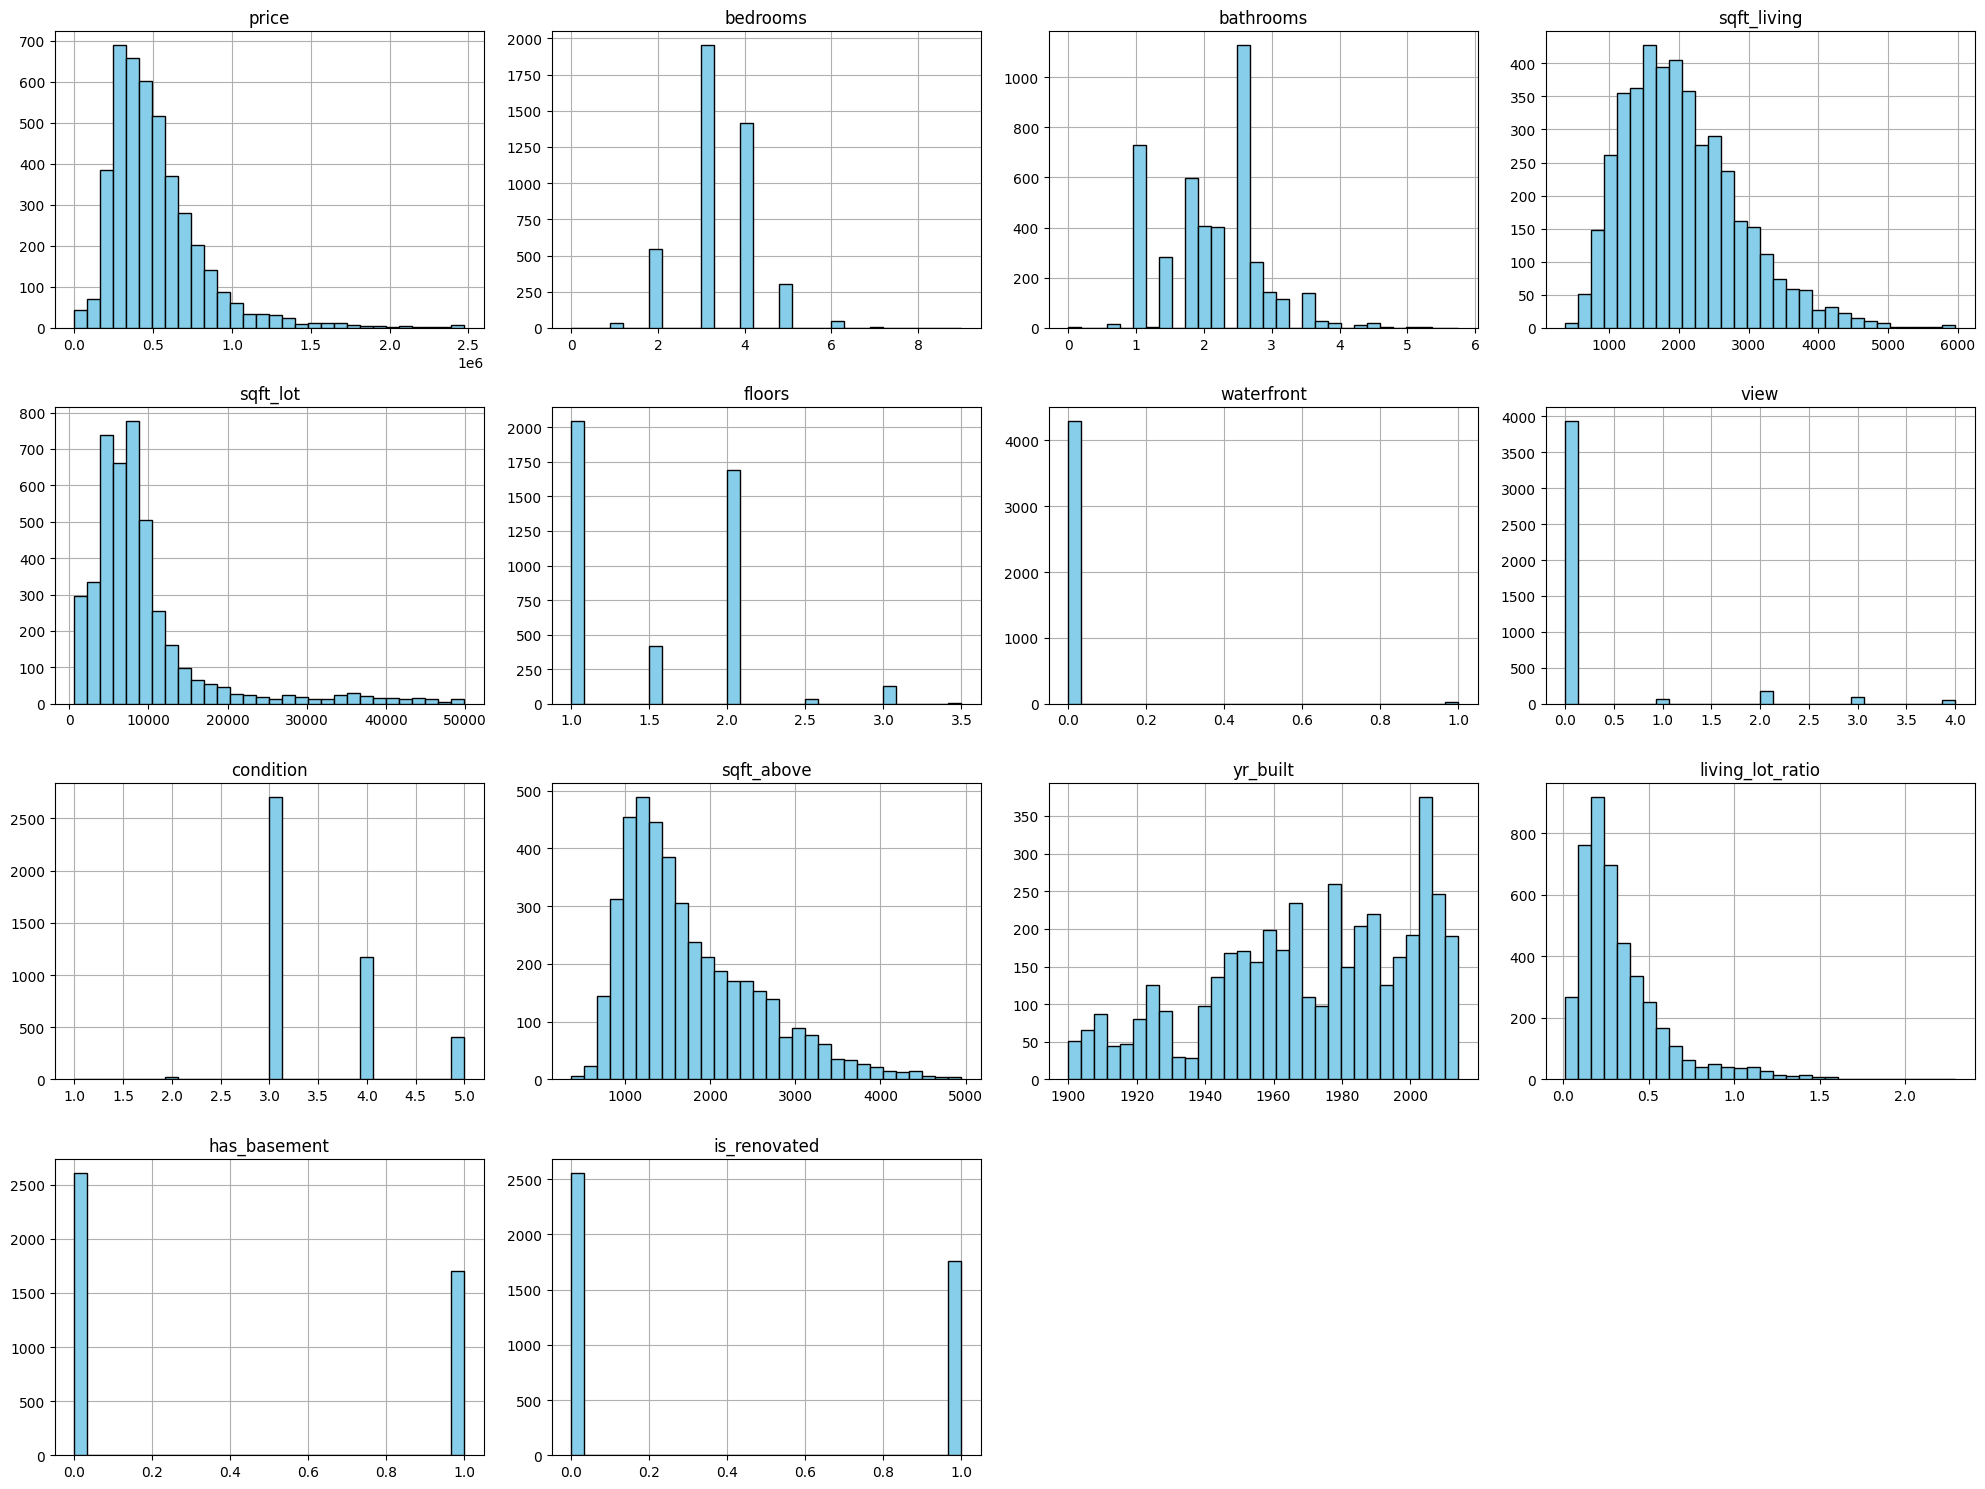

In [36]:
housing_ml.hist(edgecolor='black', bins=30, figsize=(20, 15), zorder=5, color='skyblue')
plt.tight_layout()
plt.show()

In [ ]:
columns_to_log = ['sqft_lot', 'living_lot_ratio']

housing_ml.loc[:, columns_to_log] = housing_ml.loc[:, columns_to_log].apply(lambda x: np.log1p(x))

C:\Users\user\AppData\Local\Temp\ipykernel_17656\697971577.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[8.97626226 9.11063053 9.38831918 ... 8.85580599 8.7995109  8.99998964]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  housing_ml.loc[:, columns_to_log] = housing_ml.loc[:, columns_to_log].apply(lambda x: np.log1p(x))


In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

X =  housing_ml.drop('price', axis=1)
y =  housing_ml['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, train_size=0.7)

In [43]:
scalar = StandardScaler()
X_scaled_train = scalar.fit_transform(X_train)
X_scaled_test = scalar.transform(X_test)

lin_model = LinearRegression()

lin_model.fit(X_scaled_train, y_train)

y_pred = lin_model.predict(X_scaled_test)

print(f"RMSE: {mean_squared_error(y_test, y_pred)**0.5}")
print(f"R2: {r2_score(y_test, y_pred)}")

RMSE: 221848.6712207133
R2: 0.4579871292765645


In [44]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

In [60]:
dt_model = DecisionTreeRegressor(random_state=42, max_depth=4, min_samples_split=6, min_samples_leaf=8)

dt_model.fit(X_scaled_train, y_train)
dt_pred = dt_model.predict(X_scaled_test)

print(f"RMSE: {mean_squared_error(dt_pred, y_pred)**0.5}")
print(f"R2: {r2_score(dt_pred, y_pred)}")

RMSE: 105074.39142855938
R2: 0.7706433754129763


In [63]:
gb_model = GradientBoostingRegressor(random_state=42, n_estimators=300, max_depth=4, alpha=0.3)

gb_model.fit(X_scaled_train, y_train)
gb_pred = gb_model.predict(X_scaled_test)

print(f"RMSE: {mean_squared_error(dt_pred, y_pred)**0.5}")
print(f"R2: {r2_score(dt_pred, y_pred)}")

RMSE: 105074.39142855938
R2: 0.7706433754129763


In [64]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_scaled_train, y_train)
xgb_pred = xgb_model.predict(X_scaled_train)

print(f"RMSE: {mean_squared_error(dt_pred, y_pred)**0.5}")
print(f"R2: {r2_score(dt_pred, y_pred)}")

RMSE: 105074.39142855938
R2: 0.7706433754129763
